In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("Cleaned/Merged_Data.csv")
df.head()

,date,Cleaned/ConsumerPriceIndexAllItems,Cleaned/FEDRates,Cleaned/GDP,Cleaned/InflationConsumerPrice,Cleaned/MedianConsumerPriceIndex,Cleaned/RealGDP,Cleaned/RealGDPPerCapita,Cleaned/RealPotentialGDP,Cleaned/UnemployemenrRate
0,1946-01-01,NaN,NaN,.,NaN,NaN,NaN,NaN,NaN,NaN
1,1946-04-01,NaN,NaN,.,NaN,NaN,NaN,NaN,NaN,NaN
2,1946-07-01,NaN,NaN,.,NaN,NaN,NaN,NaN,NaN,NaN
3,1946-10-01,NaN,NaN,.,NaN,NaN,NaN,NaN,NaN,NaN
4,1947-01-01,NaN,NaN,243.164,NaN,NaN,2182.681,15248.0,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   date                                972 non-null    object 
 1   Cleaned/ConsumerPriceIndexAllItems  830 non-null    float64
 2   Cleaned/FEDRates                    846 non-null    float64
 3   Cleaned/GDP                         315 non-null    object 
 4   Cleaned/InflationConsumerPrice      64 non-null     float64
 5   Cleaned/MedianConsumerPriceIndex    504 non-null    float64
 6   Cleaned/RealGDP                     311 non-null    float64
 7   Cleaned/RealGDPPerCapita            311 non-null    float64
 8   Cleaned/RealPotentialGDP            344 non-null    float64
 9   Cleaned/UnemployemenrRate           924 non-null    float64
dtypes: float64(8), object(2)
memory usage: 76.1+ KB


In [4]:
df.size

9720

In [6]:
df.shape

(972, 10)

In [7]:
df.isna().sum()

date                                    0
Cleaned/ConsumerPriceIndexAllItems    142
Cleaned/FEDRates                      126
Cleaned/GDP                           657
Cleaned/InflationConsumerPrice        908
Cleaned/MedianConsumerPriceIndex      468
Cleaned/RealGDP                       661
Cleaned/RealGDPPerCapita              661
Cleaned/RealPotentialGDP              628
Cleaned/UnemployemenrRate              48
dtype: int64

In [8]:
# Dropping all columns where there is no values in FedRates Column:
df2 = df.copy()
df2 = df.dropna(subset=['Cleaned/FEDRates'])
df2.head()

,date,Cleaned/ConsumerPriceIndexAllItems,Cleaned/FEDRates,Cleaned/GDP,Cleaned/InflationConsumerPrice,Cleaned/MedianConsumerPriceIndex,Cleaned/RealGDP,Cleaned/RealGDPPerCapita,Cleaned/RealPotentialGDP,Cleaned/UnemployemenrRate
86,1954-07-01,NaN,0.80,390.996,NaN,NaN,2880.482,17701.0,2923.974918,5.8
87,1954-08-01,NaN,1.22,NaN,NaN,NaN,NaN,NaN,NaN,6.0
88,1954-09-01,NaN,1.07,NaN,NaN,NaN,NaN,NaN,NaN,6.1
89,1954-10-01,NaN,0.85,399.734,NaN,NaN,2936.852,17960.0,2941.999753,5.7
90,1954-11-01,NaN,0.83,NaN,NaN,NaN,NaN,NaN,NaN,5.3


In [9]:
# Fill NaN values with the value from the row above in each column
df3 = df2.fillna(method='ffill')
df3.head()

C:\Users\Sangram More\AppData\Local\Temp\ipykernel_21292\3667838132.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df3 = df2.fillna(method='ffill')


,date,Cleaned/ConsumerPriceIndexAllItems,Cleaned/FEDRates,Cleaned/GDP,Cleaned/InflationConsumerPrice,Cleaned/MedianConsumerPriceIndex,Cleaned/RealGDP,Cleaned/RealGDPPerCapita,Cleaned/RealPotentialGDP,Cleaned/UnemployemenrRate
86,1954-07-01,NaN,0.80,390.996,NaN,NaN,2880.482,17701.0,2923.974918,5.8
87,1954-08-01,NaN,1.22,390.996,NaN,NaN,2880.482,17701.0,2923.974918,6.0
88,1954-09-01,NaN,1.07,390.996,NaN,NaN,2880.482,17701.0,2923.974918,6.1
89,1954-10-01,NaN,0.85,399.734,NaN,NaN,2936.852,17960.0,2941.999753,5.7
90,1954-11-01,NaN,0.83,399.734,NaN,NaN,2936.852,17960.0,2941.999753,5.3


In [10]:
# Fill NaN values with the value from the row below in each column
df4 = df3.fillna(method='bfill')
df4.head()

C:\Users\Sangram More\AppData\Local\Temp\ipykernel_21292\3554345968.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df4 = df3.fillna(method='bfill')


,date,Cleaned/ConsumerPriceIndexAllItems,Cleaned/FEDRates,Cleaned/GDP,Cleaned/InflationConsumerPrice,Cleaned/MedianConsumerPriceIndex,Cleaned/RealGDP,Cleaned/RealGDPPerCapita,Cleaned/RealPotentialGDP,Cleaned/UnemployemenrRate
86,1954-07-01,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
87,1954-08-01,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
88,1954-09-01,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
89,1954-10-01,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
90,1954-11-01,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [11]:
# exporting dataset as csv file
df4.to_csv("Cleaned/finaldataset.csv")

In [12]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 846 entries, 86 to 931
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   date                                846 non-null    object 
 1   Cleaned/ConsumerPriceIndexAllItems  846 non-null    float64
 2   Cleaned/FEDRates                    846 non-null    float64
 3   Cleaned/GDP                         846 non-null    object 
 4   Cleaned/InflationConsumerPrice      846 non-null    float64
 5   Cleaned/MedianConsumerPriceIndex    846 non-null    float64
 6   Cleaned/RealGDP                     846 non-null    float64
 7   Cleaned/RealGDPPerCapita            846 non-null    float64
 8   Cleaned/RealPotentialGDP            846 non-null    float64
 9   Cleaned/UnemployemenrRate           846 non-null    float64
dtypes: float64(8), object(2)
memory usage: 72.7+ KB


In [17]:
df5 = df4.copy()
df5['Cleaned/GDP'] = df5['Cleaned/GDP'].replace(".", np.nan)

In [18]:
df5.fillna(method='ffill')
df5.isna().sum()

C:\Users\Sangram More\AppData\Local\Temp\ipykernel_21292\1136554010.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df5.fillna(method='ffill')


date                                  0
Cleaned/ConsumerPriceIndexAllItems    0
Cleaned/FEDRates                      0
Cleaned/GDP                           0
Cleaned/InflationConsumerPrice        0
Cleaned/MedianConsumerPriceIndex      0
Cleaned/RealGDP                       0
Cleaned/RealGDPPerCapita              0
Cleaned/RealPotentialGDP              0
Cleaned/UnemployemenrRate             0
dtype: int64

In [19]:
df5['Cleaned/GDP'] = pd.to_numeric(df5['Cleaned/GDP'])
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 846 entries, 86 to 931
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   date                                846 non-null    object 
 1   Cleaned/ConsumerPriceIndexAllItems  846 non-null    float64
 2   Cleaned/FEDRates                    846 non-null    float64
 3   Cleaned/GDP                         846 non-null    float64
 4   Cleaned/InflationConsumerPrice      846 non-null    float64
 5   Cleaned/MedianConsumerPriceIndex    846 non-null    float64
 6   Cleaned/RealGDP                     846 non-null    float64
 7   Cleaned/RealGDPPerCapita            846 non-null    float64
 8   Cleaned/RealPotentialGDP            846 non-null    float64
 9   Cleaned/UnemployemenrRate           846 non-null    float64
dtypes: float64(9), object(1)
memory usage: 72.7+ KB


In [20]:
df5.to_csv("Cleaned/finaldataset.csv")

In [35]:
df5 = pd.read_csv("Cleaned/finaldataset.csv")
df5['date'] = pd.to_datetime(df5['date'])
df5.drop('Unnamed: 0', axis=1, inplace=True)
df5.head()

,date,ConsumerPriceIndexAllItems,FEDRates,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,1954-07-01,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
1,1954-08-01,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
2,1954-09-01,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
3,1954-10-01,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
4,1954-11-01,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [41]:
df5.to_csv("Cleaned/finaldataset.csv", index=False)

In [42]:
a = pd.read_csv("Cleaned/finaldataset.csv")
a.head()

,date,ConsumerPriceIndexAllItems,FEDRates,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,1954-07-01,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
1,1954-08-01,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
2,1954-09-01,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
3,1954-10-01,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
4,1954-11-01,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [44]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        846 non-null    object 
 1   ConsumerPriceIndexAllItems  846 non-null    float64
 2   FEDRates                    846 non-null    float64
 3   GDP                         846 non-null    float64
 4   InflationConsumerPrice      846 non-null    float64
 5   MedianConsumerPriceIndex    846 non-null    float64
 6   RealGDP                     846 non-null    float64
 7   RealGDPPerCapita            846 non-null    float64
 8   RealPotentialGDP            846 non-null    float64
 9   UnemployemenrRate           846 non-null    float64
dtypes: float64(9), object(1)
memory usage: 66.2+ KB


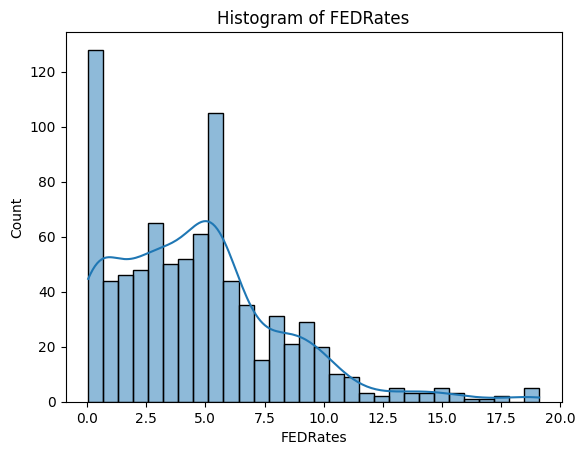

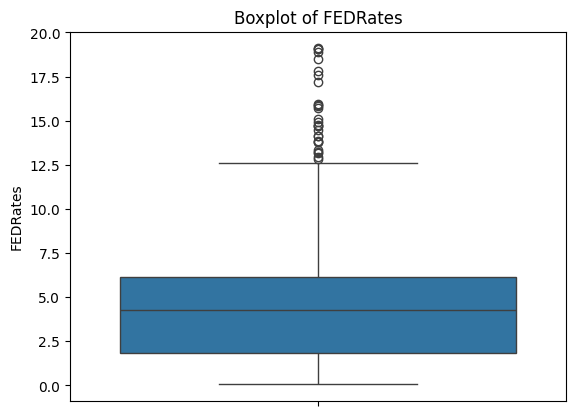

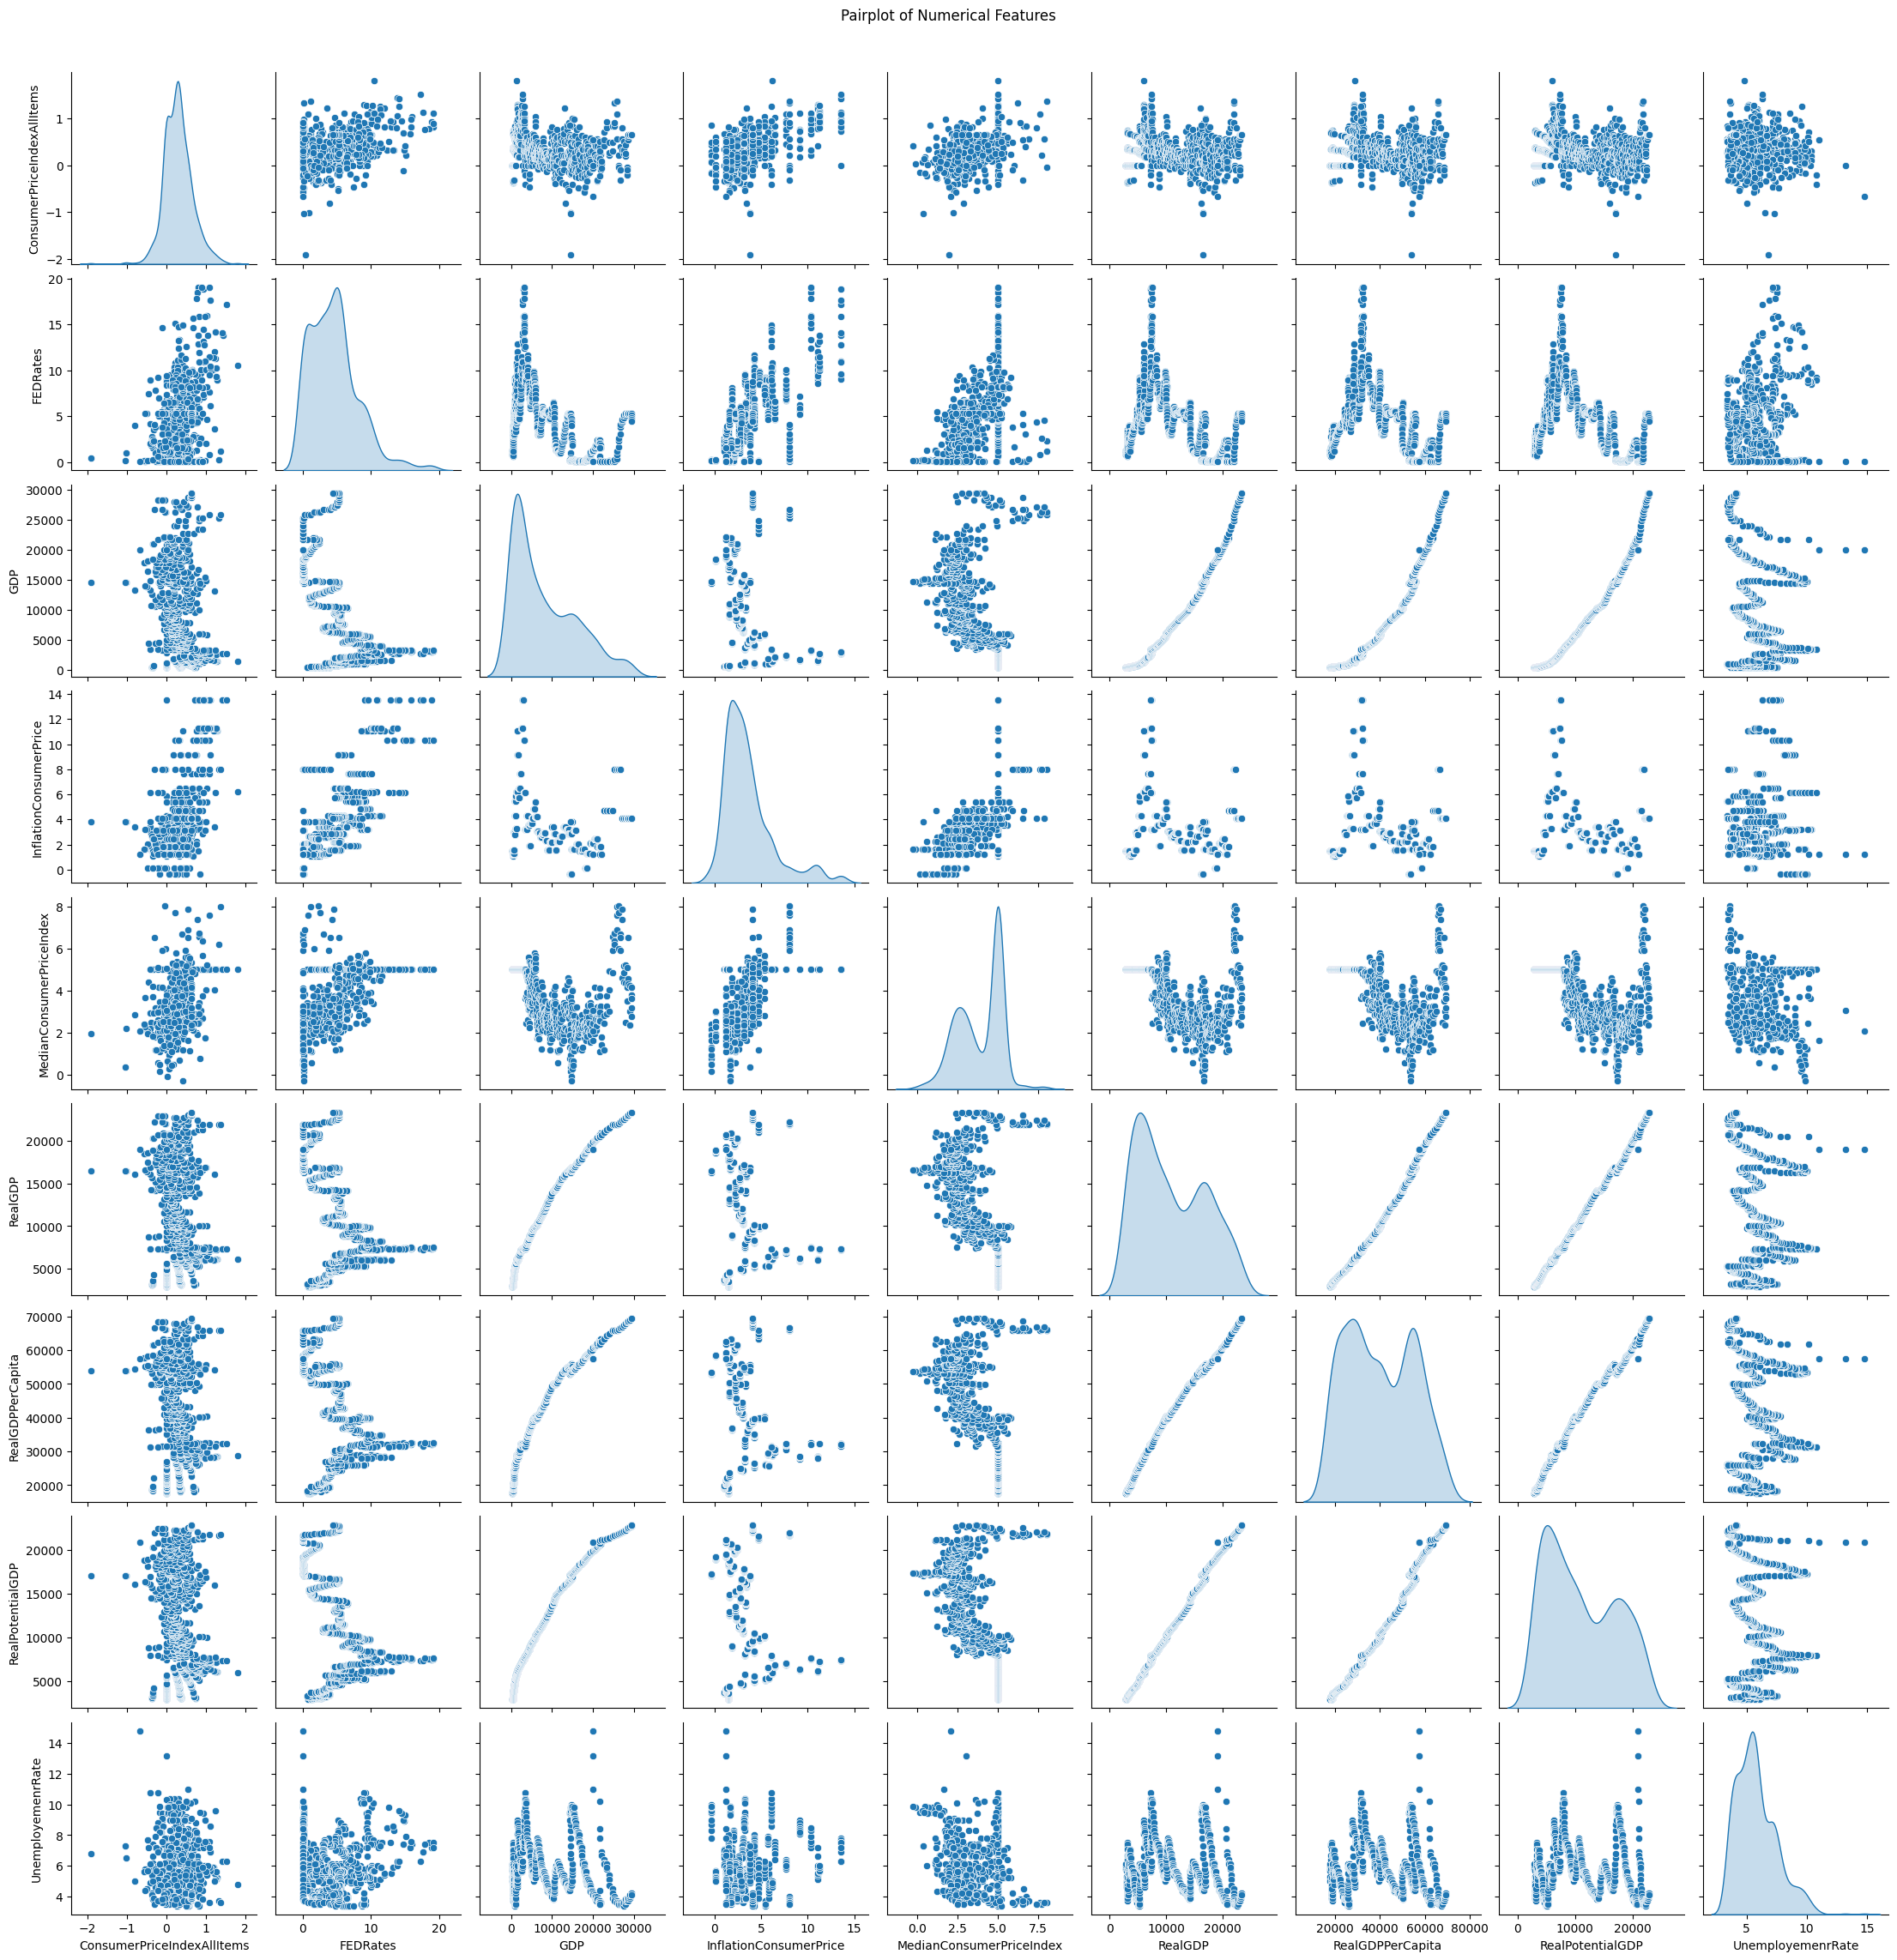

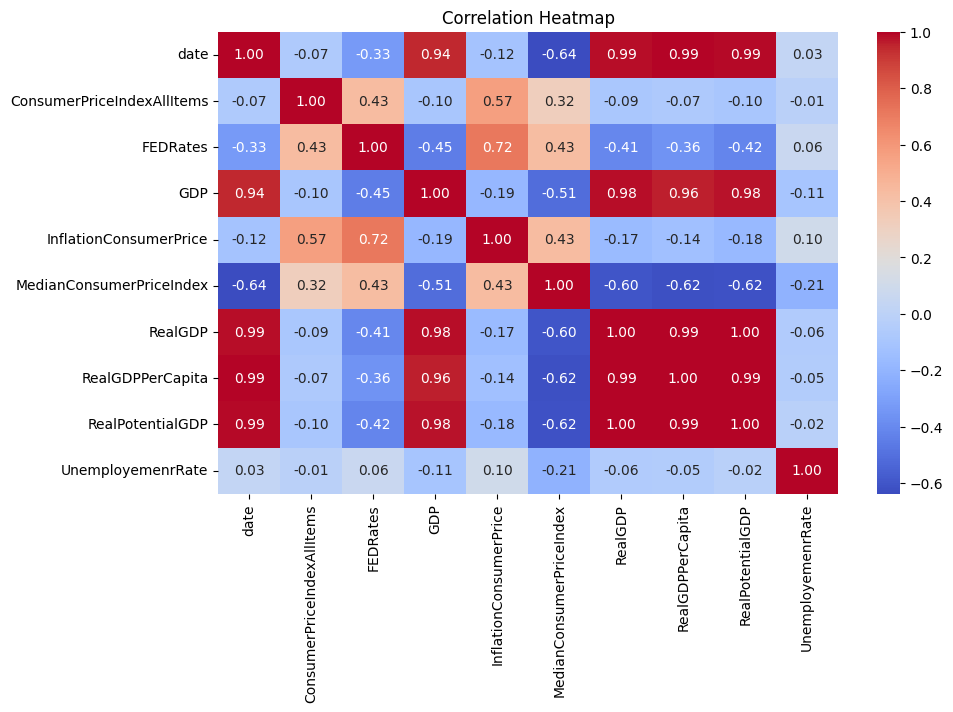

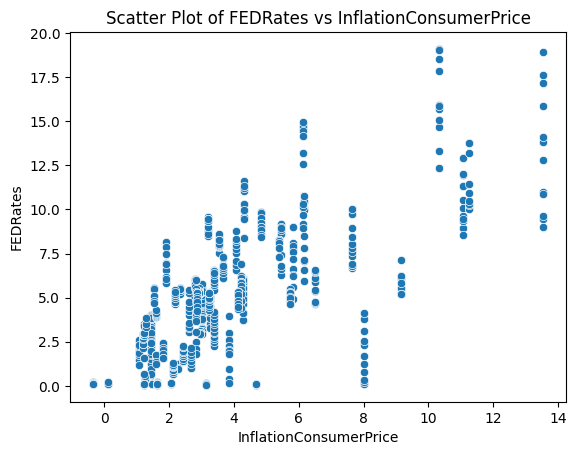

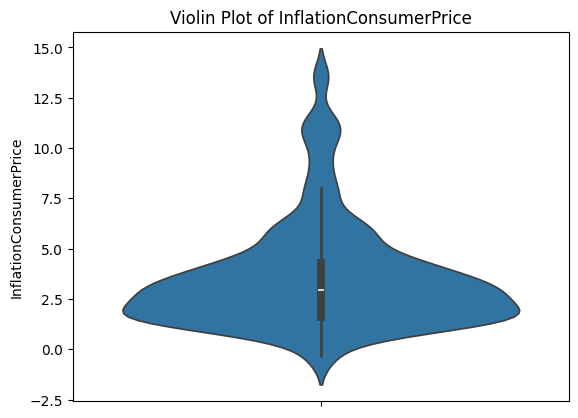

C:\Users\Sangram More\AppData\Local\Temp\ipykernel_21292\4036152075.py:57: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[target_variable], ax=ax, shade=True)


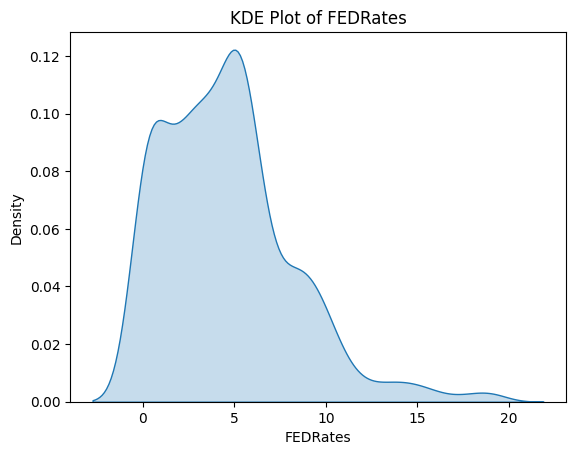

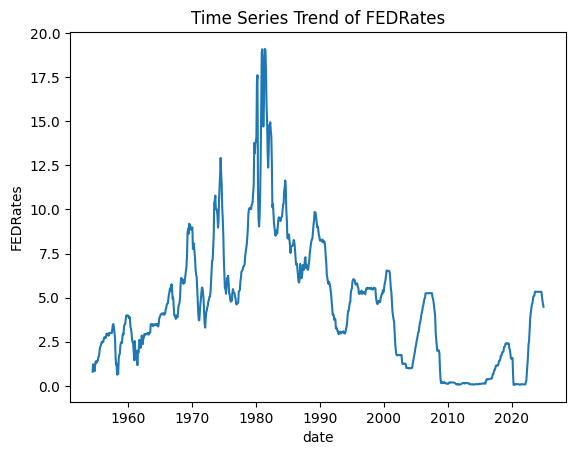

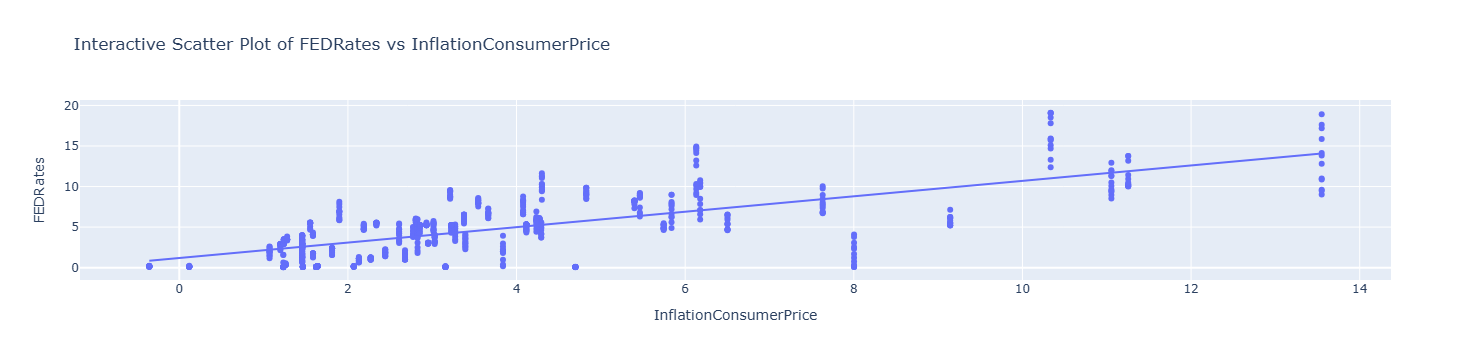

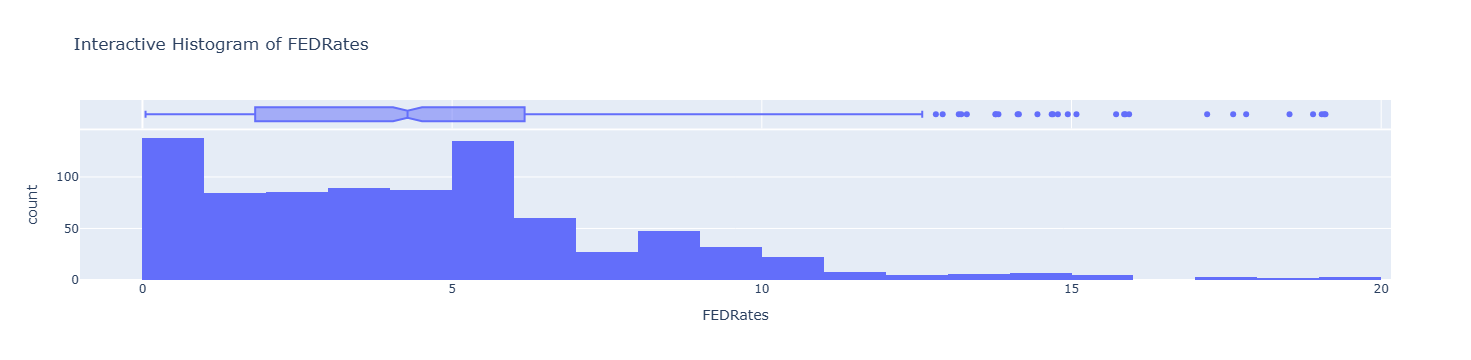

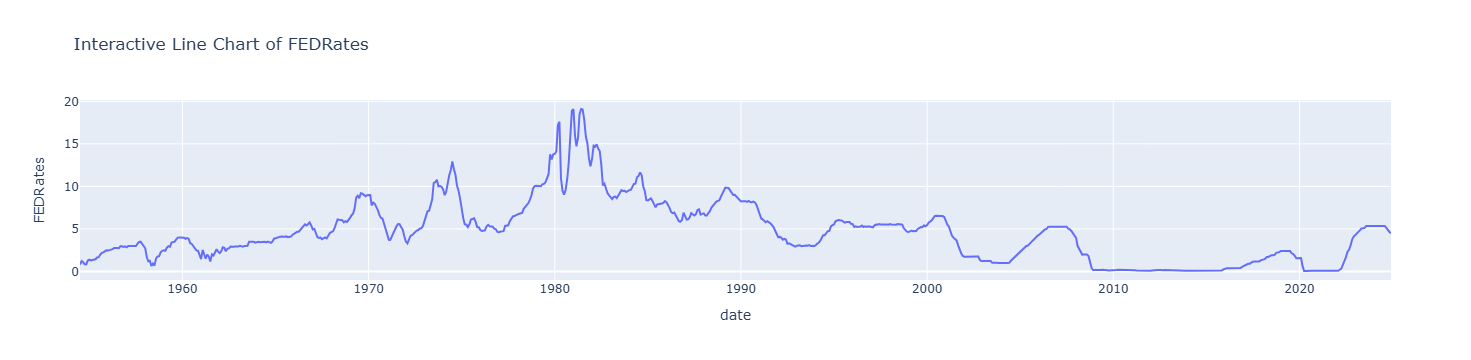

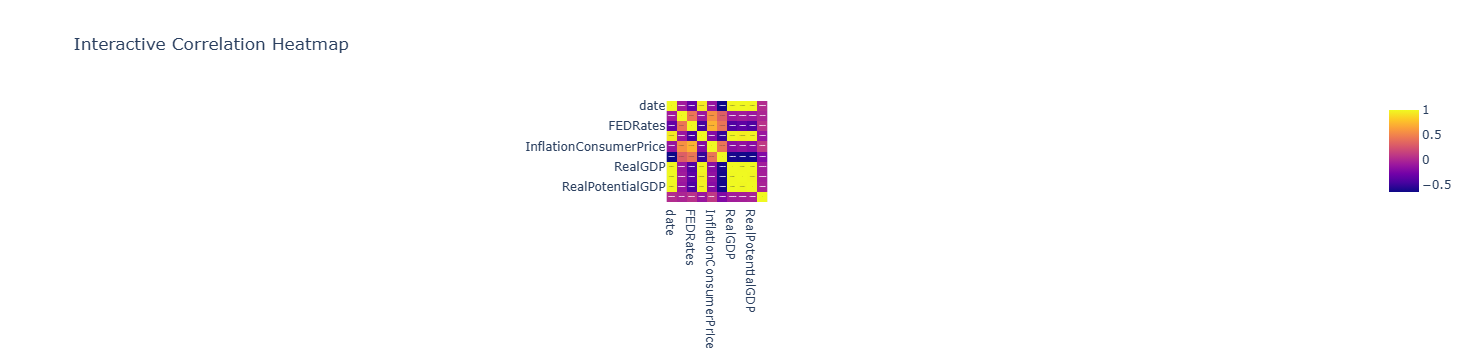

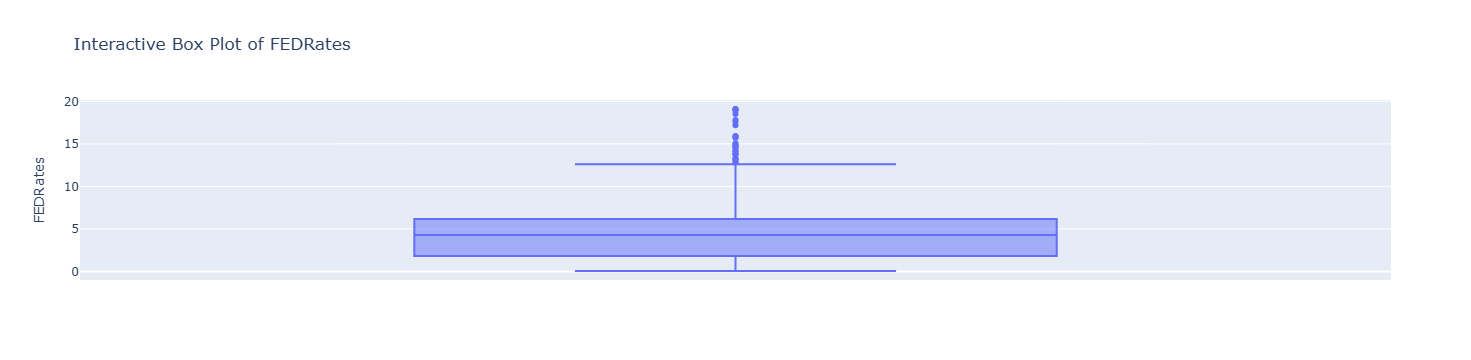

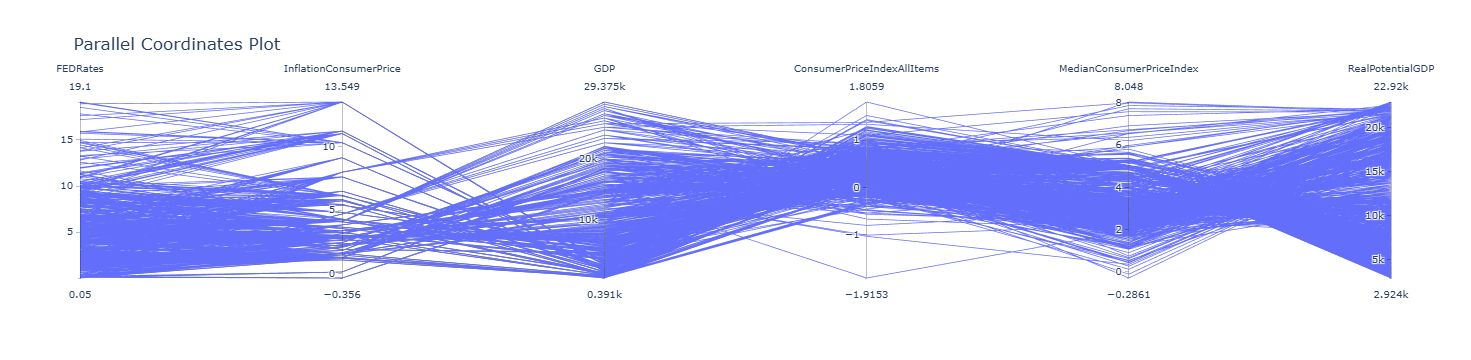

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the dataset
file_path = "Cleaned/finaldataset.csv"  # Update with your actual file path
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])
# Set the target variable
target_variable = "FEDRates"

# Store figures
figures = []

### Matplotlib & Seaborn Plots ###

# 1. Histogram of the target variable
fig, ax = plt.subplots()
sns.histplot(df[target_variable], bins=30, kde=True, ax=ax)
ax.set_title(f"Histogram of {target_variable}")
plt.show()

# 2. Boxplot of the target variable to detect outliers
fig, ax = plt.subplots()
sns.boxplot(y=df[target_variable], ax=ax)
ax.set_title(f"Boxplot of {target_variable}")
plt.show()

# 3. Pairplot for numerical relationships
fig = sns.pairplot(df.select_dtypes(include=['number']), diag_kind="kde")
fig.fig.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()

# 4. Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

# 5. Scatter Plot of two most correlated variables with target
correlations = df.corr()[target_variable].abs().sort_values(ascending=False)
top_feature = correlations.index[1]  # The most correlated feature with target
fig, ax = plt.subplots()
sns.scatterplot(x=df[top_feature], y=df[target_variable], ax=ax)
ax.set_title(f"Scatter Plot of {target_variable} vs {top_feature}")
plt.show()

# 6. Violin Plot of a numerical feature
fig, ax = plt.subplots()
sns.violinplot(y=df[top_feature], ax=ax)
ax.set_title(f"Violin Plot of {top_feature}")
plt.show()

# 7. KDE plot for target variable
fig, ax = plt.subplots()
sns.kdeplot(df[target_variable], ax=ax, shade=True)
ax.set_title(f"KDE Plot of {target_variable}")
plt.show()

# 8. Countplot of a categorical column if available
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    fig, ax = plt.subplots()
    sns.countplot(x=df[categorical_cols[0]], ax=ax)
    ax.set_title(f"Countplot of {categorical_cols[0]}")
    plt.show()

# 9. Line Plot of the target variable over time if date column exists
date_cols = [col for col in df.columns if 'date' in col.lower()]
if len(date_cols) > 0:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]], errors='coerce')
    df_sorted = df.sort_values(by=date_cols[0])
    fig, ax = plt.subplots()
    sns.lineplot(x=df_sorted[date_cols[0]], y=df_sorted[target_variable], ax=ax)
    ax.set_title(f"Time Series Trend of {target_variable}")
    plt.show()

### Plotly Interactive Plots ###

# 10. Interactive Scatter Plot of target vs top correlated feature
fig = px.scatter(df, x=top_feature, y=target_variable,
                 title=f"Interactive Scatter Plot of {target_variable} vs {top_feature}",
                 trendline="ols")
fig.show()

# 11. Interactive Histogram of target variable
fig = px.histogram(df, x=target_variable, title=f"Interactive Histogram of {target_variable}", nbins=30, marginal="box")
fig.show()

# 12. Interactive Line Chart if date column exists
if len(date_cols) > 0:
    fig = px.line(df_sorted, x=date_cols[0], y=target_variable, title=f"Interactive Line Chart of {target_variable}")
    fig.show()

# 13. Interactive Heatmap
fig = px.imshow(df.corr(), text_auto=True, title="Interactive Correlation Heatmap")
fig.show()

# 14. Interactive Box Plot of target variable
fig = px.box(df, y=target_variable, title=f"Interactive Box Plot of {target_variable}")
fig.show()

# 15. Interactive Parallel Coordinates plot for top correlated features
top_features = correlations.index[1:6]  # Top 5 most correlated features
fig = px.parallel_coordinates(df, dimensions=[target_variable] + list(top_features), title="Parallel Coordinates Plot")
fig.show()


In [47]:
pip install statsmodels

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ----------- ---------------------------- 2.9/9.8 MB 16.4 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.8 MB 19.7 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 17.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip
